# WTI 현물가격 예측: LSTM / Transformer / PatchTST
# — Walk-Forward CV + Target Transform × Univariate 실험

이 노트북은 **2 × 2 실험 설계** 로 총 4개 조합을 비교합니다.

|              | Multivariate (target + 6 외생변수) | Univariate (target only) |
|--------------|-----|-----|
| **Raw price**    | 실험 A (baseline)      | 실험 B      |
| **Log-return**   | 실험 C     | 실험 D      |

각 조합에 대해 LSTM / Transformer / PatchTST 3 모델을 walk-forward CV로 학습·평가합니다.

## Log-return 정의 (shift log-return)
$$r_t = \log(p_t + C) - \log(p_{t-1} + C), \quad C = 50$$
- WTI는 2020년 4월 음수 가격(-$36.98)이 있어 순수 log(p) 불가능
- shift C=50으로 모든 가격을 양수로 만든 뒤 로그를 취함
- 예측 후 anchor + cumsum → exp → shift 빼기 로 원 가격 복원

## 공정 비교를 위한 metric
- **CV loss (Optuna 목적함수)**: 각 target 스케일에서의 MSE (정규화 후)
- **Test metric (리포트용)**: 항상 **원 가격 스케일** RMSE/MAE/MAPE


## 1. 임포트 및 환경

In [ ]:
# !pip install torch pandas numpy scikit-learn matplotlib optuna tqdm


In [4]:
import os, random, math, json, copy
from dataclasses import dataclass, field, asdict
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import optuna
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)


Device: cuda
Torch: 2.3.1+cu121


/home/jjh/miniconda3/envs/flexgen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 설정 (Config)

**신규 필드**
- `target_transform`: `"raw"` 또는 `"log_return"`
- `log_shift`: log-return용 shift 상수 C (기본 50)
- `use_exogenous`: True면 6개 외생변수 포함, False면 target 만 입력 (univariate)


In [5]:
@dataclass
class Config:
    # ---- 데이터 ----
    data_path: str = "/home/jjh/wti_project/data/WTI_data.csv"
    target_col: str = "WTI_Spot"
    feature_cols: List[str] = field(default_factory=lambda: [
        "Supply_Chain_Pressure",
        "Geopolitical_Risk_GPR",
        "Oil_Volatility_OVX",
        "Yield_Curve_10Y2Y",
        "WTI_Futures",
        "US_Dollar_Index",
    ])
    use_exogenous: bool = True        # ← multivariate(True) vs univariate(False)

    # ---- Target 변환 ----
    target_transform: str = "raw"     # "raw" | "log_return"
    log_shift: float = 50.0           # shift 상수 C (음수 가격 방어)

    forecast_horizon: int = 30
    lookback: int = 96

    # ---- Walk-Forward CV ----
    n_folds: int = 10
    val_fold_size: int = 30
    gap_between_train_and_val: bool = True

    # ---- 학습 ----
    batch_size: int = 64
    epochs: int = 60
    lr: float = 1e-3
    weight_decay: float = 1e-5
    grad_clip: float = 1.0
    patience: int = 12
    num_workers: int = 0

    # ---- LSTM ----
    lstm_hidden: int = 128
    lstm_layers: int = 2
    lstm_dropout: float = 0.1

    # ---- Transformer ----
    tf_d_model: int = 64
    tf_nhead: int = 4
    tf_layers: int = 2
    tf_dim_ff: int = 128
    tf_dropout: float = 0.1

    # ---- PatchTST ----
    patch_len: int = 16
    stride: int = 8
    pt_d_model: int = 64
    pt_nhead: int = 4
    pt_layers: int = 3
    pt_dim_ff: int = 128
    pt_dropout: float = 0.1
    pt_revin: bool = True

    seed: int = 42

CFG = Config()
CFG


Config(data_path='/home/jjh/wti_project/data/WTI_data.csv', target_col='WTI_Spot', feature_cols=['Supply_Chain_Pressure', 'Geopolitical_Risk_GPR', 'Oil_Volatility_OVX', 'Yield_Curve_10Y2Y', 'WTI_Futures', 'US_Dollar_Index'], use_exogenous=True, target_transform='raw', log_shift=50.0, forecast_horizon=30, lookback=96, n_folds=10, val_fold_size=30, gap_between_train_and_val=True, batch_size=64, epochs=60, lr=0.001, weight_decay=1e-05, grad_clip=1.0, patience=12, num_workers=0, lstm_hidden=128, lstm_layers=2, lstm_dropout=0.1, tf_d_model=64, tf_nhead=4, tf_layers=2, tf_dim_ff=128, tf_dropout=0.1, patch_len=16, stride=8, pt_d_model=64, pt_nhead=4, pt_layers=3, pt_dim_ff=128, pt_dropout=0.1, pt_revin=True, seed=42)

In [6]:
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)


## 3. 데이터 로딩, Target 변환, 스케일링

**변환 파이프라인**
1. 원 가격 `p_t` 로드
2. `target_transform` 에 따라 학습 타깃 계산:
   - `raw`: `y_t = p_t`
   - `log_return`: `y_t = log(p_t + C) - log(p_{t-1} + C)`, `y_0 = 0` (padding)
3. 입력 배열 = [학습 타깃] + (옵션) [외생변수 6개]
4. StandardScaler로 정규화 (cv_start 이전에만 fit)

**역변환 (테스트 예측 → 가격 복원)**
- `raw`: 역스케일 = 가격
- `log_return`: 역스케일 → 예측 return → cumsum → anchor(마지막 알려진 가격의 shifted-log) 더함 → exp → shift 빼기


In [7]:
def load_data(cfg: Config) -> pd.DataFrame:
    df = pd.read_csv(cfg.data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    return df

df = load_data(CFG)
print("Shape:", df.shape, " Range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Price range:", df[CFG.target_col].min(), "~", df[CFG.target_col].max())
print(f"Negative-price days: {(df[CFG.target_col] < 0).sum()}")


Shape: (9678, 8)  Range: 2000-01-01 → 2026-06-30
Price range: -36.98 ~ 145.31
Negative-price days: 1


In [8]:
def make_splits(df, cfg) -> Tuple[int, int]:
    n = len(df)
    test_start = n - cfg.forecast_horizon
    cv_start = test_start - cfg.n_folds * cfg.val_fold_size
    assert cv_start > cfg.lookback, "lookback + CV + test 가 데이터 길이보다 김"
    return cv_start, test_start

def fold_boundaries(df, cfg, fold_idx) -> Tuple[int, int]:
    cv_start, _ = make_splits(df, cfg)
    return cv_start + fold_idx * cfg.val_fold_size, cv_start + (fold_idx+1) * cfg.val_fold_size

cv_start, test_start = make_splits(df, CFG)
print(f"cv_start={cv_start}, test_start={test_start}")
print(f"test period: {df['Date'].iloc[test_start].date()} → {df['Date'].iloc[-1].date()}")


cv_start=9348, test_start=9648
test period: 2026-06-01 → 2026-06-30


In [9]:
def apply_target_transform(prices: np.ndarray, cfg: Config):
    """원 가격 → 학습 타깃. 나중에 역변환에 필요한 anchor 재료도 함께 반환."""
    if cfg.target_transform == "raw":
        y = prices.astype(np.float32).copy()
        shifted_log = None
    elif cfg.target_transform == "log_return":
        # 모든 가격을 양수로: shift 후 log
        shifted = prices + cfg.log_shift
        assert (shifted > 0).all(), (
            f"log_shift={cfg.log_shift} 가 최소 가격 {prices.min():.2f} 을 양수로 못 만듦")
        shifted_log = np.log(shifted).astype(np.float32)
        # log-return: y_t = shifted_log_t - shifted_log_{t-1}, y_0 = 0
        y = np.zeros_like(shifted_log)
        y[1:] = shifted_log[1:] - shifted_log[:-1]
    else:
        raise ValueError(cfg.target_transform)
    return y, shifted_log


def inverse_target_to_price(pred_target: np.ndarray, anchor_shifted_log: Optional[float],
                            cfg: Config) -> np.ndarray:
    """예측 target(원 스케일, 스케일러 unscale 후) → 예측 가격.

    pred_target: (n_samples, H) 또는 (H,)
    anchor_shifted_log: log_return 모드에서 예측 창 직전 시점의 log(p + C). (필수)
    """
    if cfg.target_transform == "raw":
        return pred_target
    elif cfg.target_transform == "log_return":
        assert anchor_shifted_log is not None
        # horizon 축에서 cumsum
        if pred_target.ndim == 1:
            cum = np.cumsum(pred_target)
        else:
            cum = np.cumsum(pred_target, axis=-1)
        shifted_log_pred = anchor_shifted_log + cum
        return np.exp(shifted_log_pred) - cfg.log_shift
    else:
        raise ValueError(cfg.target_transform)


def prepare_arrays(df: pd.DataFrame, cfg: Config):
    """입력 배열 X (channels), 학습 타깃 y, 스케일러, 원 가격 및 shifted_log 반환."""
    cv_start, _ = make_splits(df, cfg)
    raw_prices = df[cfg.target_col].values.astype(np.float32)
    y_transformed, shifted_log = apply_target_transform(raw_prices, cfg)

    # 입력 채널 구성
    channels = [y_transformed]
    if cfg.use_exogenous:
        for c in cfg.feature_cols:
            channels.append(df[c].values.astype(np.float32))
    data = np.stack(channels, axis=1)     # (N, F)

    # 스케일러 (cv_start 이전만 사용)
    feat_scaler = StandardScaler().fit(data[:cv_start])
    X_scaled = feat_scaler.transform(data).astype(np.float32)

    target_scaler = StandardScaler().fit(data[:cv_start, 0:1])
    y_scaled = target_scaler.transform(data[:, 0:1]).astype(np.float32).ravel()

    channel_names = [cfg.target_col + f"[{cfg.target_transform}]"]
    if cfg.use_exogenous:
        channel_names += cfg.feature_cols

    return {
        "X": X_scaled, "y": y_scaled,
        "target_scaler": target_scaler, "feat_scaler": feat_scaler,
        "raw_prices": raw_prices, "shifted_log": shifted_log,
        "channel_names": channel_names,
    }


# 기본 CFG 로 확인
_prep = prepare_arrays(df, CFG)
print("channels:", _prep["channel_names"])
print("X:", _prep["X"].shape, " y:", _prep["y"].shape)


channels: ['WTI_Spot[raw]', 'Supply_Chain_Pressure', 'Geopolitical_Risk_GPR', 'Oil_Volatility_OVX', 'Yield_Curve_10Y2Y', 'WTI_Futures', 'US_Dollar_Index']
X: (9678, 7)  y: (9678,)


## 4. Dataset & Loader (Walk-forward)

In [10]:
class SeqDataset(Dataset):
    def __init__(self, X, y, idx_start, idx_end, lookback, horizon):
        starts = []
        for t in range(idx_start, idx_end):
            if t - lookback >= 0 and t + horizon <= len(y):
                starts.append(t)
        self.X, self.y = X, y
        self.lookback, self.horizon = lookback, horizon
        self.starts = np.array(starts, dtype=np.int64)
    def __len__(self): return len(self.starts)
    def __getitem__(self, i):
        t = self.starts[i]
        return (torch.from_numpy(self.X[t-self.lookback:t]),
                torch.from_numpy(self.y[t:t+self.horizon]))


def build_fold_loaders(cfg, X, y, fold_idx):
    val_start, val_end = fold_boundaries(df, cfg, fold_idx)
    H = cfg.forecast_horizon
    train_end = val_start - H + 1 if cfg.gap_between_train_and_val else val_start
    train_ds = SeqDataset(X, y, cfg.lookback, train_end, cfg.lookback, H)
    val_ds = SeqDataset(X, y, val_start, val_end - H + 1, cfg.lookback, H)
    tr = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                    num_workers=cfg.num_workers, drop_last=False)
    va = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                    num_workers=cfg.num_workers)
    return tr, va, val_start   # val_start = 나중 anchor 계산용


def build_final_train_loader(cfg, X, y):
    _, test_start = make_splits(df, cfg)
    H = cfg.forecast_horizon
    train_end = test_start - H + 1 if cfg.gap_between_train_and_val else test_start
    ds = SeqDataset(X, y, cfg.lookback, train_end, cfg.lookback, H)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=True,
                      num_workers=cfg.num_workers, drop_last=False)


def build_test_loader(cfg, X, y):
    _, test_start = make_splits(df, cfg)
    ds = SeqDataset(X, y, test_start, test_start + 1, cfg.lookback, cfg.forecast_horizon)
    return DataLoader(ds, batch_size=1, shuffle=False)


## 5. 모델 정의 (이전 버전과 동일)

In [11]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden, num_layers, horizon, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, horizon),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]


class TransformerForecaster(nn.Module):
    def __init__(self, n_features, d_model, nhead, num_layers, dim_ff, horizon, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, horizon))
    def forward(self, x):
        z = self.pos_enc(self.input_proj(x))
        return self.head(self.encoder(z).mean(dim=1))


class RevIN(nn.Module):
    def __init__(self, n_features, eps=1e-5, affine=True):
        super().__init__()
        self.n_features, self.eps, self.affine = n_features, eps, affine
        if affine:
            self.weight = nn.Parameter(torch.ones(n_features))
            self.bias = nn.Parameter(torch.zeros(n_features))
    def forward(self, x, mode):
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = x.std(dim=1, keepdim=True, unbiased=False).detach() + self.eps
            x = (x - self.mean) / self.stdev
            if self.affine: x = x * self.weight + self.bias
            return x
        elif mode == "denorm":
            if self.affine: x = (x - self.bias) / (self.weight + self.eps*self.eps)
            return x * self.stdev + self.mean


class PatchTST(nn.Module):
    def __init__(self, n_features, lookback, horizon, patch_len, stride,
                 d_model, nhead, num_layers, dim_ff, dropout=0.1, use_revin=True):
        super().__init__()
        self.n_features, self.horizon = n_features, horizon
        self.patch_len, self.stride, self.use_revin = patch_len, stride, use_revin
        self.pad_len = stride
        self.num_patches = (lookback + self.pad_len - patch_len) // stride + 1
        if use_revin: self.revin = RevIN(n_features)
        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.num_patches * d_model, horizon)
    def forward(self, x):
        B, L, F = x.shape
        if self.use_revin: x = self.revin(x, mode="norm")
        x = x.permute(0, 2, 1)
        pad = x[:, :, -1:].repeat(1, 1, self.pad_len)
        x = torch.cat([x, pad], dim=-1)
        x = x.unfold(-1, self.patch_len, self.stride)
        n = x.size(2)
        x = x.reshape(B*F, n, self.patch_len)
        z = self.patch_embed(x) + self.pos_embed[:, :n, :]
        z = self.dropout(z)
        z = self.encoder(z).reshape(B*F, n * z.size(-1))
        pred = self.head(z).reshape(B, F, self.horizon)
        if self.use_revin:
            pred = pred.permute(0, 2, 1)
            pred = self.revin(pred, mode="denorm")
            pred = pred.permute(0, 2, 1)
        return pred[:, 0, :]


def build_model(name, cfg, n_features):
    name = name.lower()
    if name == "lstm":
        return LSTMForecaster(n_features, cfg.lstm_hidden, cfg.lstm_layers,
                              cfg.forecast_horizon, cfg.lstm_dropout)
    if name == "transformer":
        return TransformerForecaster(n_features, cfg.tf_d_model, cfg.tf_nhead,
                                     cfg.tf_layers, cfg.tf_dim_ff,
                                     cfg.forecast_horizon, cfg.tf_dropout)
    if name == "patchtst":
        return PatchTST(n_features, cfg.lookback, cfg.forecast_horizon,
                        cfg.patch_len, cfg.stride,
                        cfg.pt_d_model, cfg.pt_nhead, cfg.pt_layers, cfg.pt_dim_ff,
                        cfg.pt_dropout, cfg.pt_revin)
    raise ValueError(name)


## 6. 학습 / 예측 유틸리티

`predict_test_price` 가 새로 추가됩니다:
1. 모델 예측(scaled) → 스케일러 unscale (target space)
2. `target_transform == log_return` 이면 anchor + cumsum → exp → shift 빼기
3. 항상 **원 가격 스케일** 로 (예측, 실제) 반환


In [12]:
def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train(); total, n = 0.0, 0
    for x, y in loader:
        x = x.to(DEVICE); y = y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y); loss.backward()
        if grad_clip: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total += loss.item() * x.size(0); n += x.size(0)
    return total / max(n, 1)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total, n = 0.0, 0
    for x, y in loader:
        x = x.to(DEVICE); y = y.to(DEVICE)
        total += criterion(model(x), y).item() * x.size(0); n += x.size(0)
    return total / max(n, 1)

def fit_with_val(model, tr, va, cfg, verbose=False):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    crit = nn.MSELoss()
    best_val, best_epoch, best_state, bad = float("inf"), 0, None, 0
    hist = {"train": [], "val": []}
    for ep in range(1, cfg.epochs + 1):
        trl = train_one_epoch(model, tr, opt, crit, cfg.grad_clip)
        vl = evaluate(model, va, crit); sch.step()
        hist["train"].append(trl); hist["val"].append(vl)
        if vl < best_val - 1e-6:
            best_val, best_epoch = vl, ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= cfg.patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, hist, best_val, best_epoch

def fit_no_val(model, tr, cfg, epochs):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(epochs, 1))
    crit = nn.MSELoss()
    hist = {"train": []}
    for _ in range(epochs):
        hist["train"].append(train_one_epoch(model, tr, opt, crit, cfg.grad_clip))
        sch.step()
    return model, hist


@torch.no_grad()
def predict_test_price(model, test_loader, prep: dict, cfg: Config):
    """예측을 원 가격 스케일로 반환. (pred_price, actual_price) 각각 (n_samples, H)."""
    _, test_start = make_splits(df, cfg)
    model.eval()
    preds = []
    for x, _ in test_loader:
        preds.append(model(x.to(DEVICE)).cpu().numpy())
    preds = np.concatenate(preds, axis=0)                       # (n, H) scaled
    # 스케일러 역변환 → target space
    pred_target = prep["target_scaler"].inverse_transform(
        preds.reshape(-1, 1)).reshape(preds.shape)              # (n, H)

    # target space → 가격
    if cfg.target_transform == "raw":
        pred_price = pred_target
    else:  # log_return
        anchor = prep["shifted_log"][test_start - 1]           # 마지막 알려진 시점
        pred_price = inverse_target_to_price(pred_target, anchor, cfg)

    actual_price = prep["raw_prices"][test_start:test_start + cfg.forecast_horizon]
    actual_price = actual_price.reshape(1, -1).repeat(pred_price.shape[0], axis=0)
    return pred_price, actual_price


@torch.no_grad()
def predict_fold_val_price(model, val_loader, prep: dict, cfg: Config, val_start: int):
    """CV fold 검증구간 예측을 원 가격 스케일로. val_loader 는 fold 당 샘플 1개 상정."""
    model.eval()
    preds = []
    for x, _ in val_loader:
        preds.append(model(x.to(DEVICE)).cpu().numpy())
    if not preds: return None, None
    preds = np.concatenate(preds, axis=0)
    pred_target = prep["target_scaler"].inverse_transform(
        preds.reshape(-1, 1)).reshape(preds.shape)
    if cfg.target_transform == "raw":
        pred_price = pred_target
    else:
        anchor = prep["shifted_log"][val_start - 1]
        pred_price = inverse_target_to_price(pred_target, anchor, cfg)
    actual_price = prep["raw_prices"][val_start:val_start + cfg.forecast_horizon]
    actual_price = actual_price.reshape(1, -1).repeat(pred_price.shape[0], axis=0)
    return pred_price, actual_price


def compute_metrics(pred, actual) -> Dict[str, float]:
    pred, actual = pred.ravel(), actual.ravel()
    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, pred))),
        "MAE": float(mean_absolute_error(actual, pred)),
        "MAPE(%)": float(np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100),
    }


## 7. Walk-Forward CV 러너 (transform-aware)

각 fold 에서:
- 학습: transform된 타깃(정규화) 으로 MSE 최소화
- Best epoch 저장
- 검증 예측: 원 가격 복원 후 fold RMSE 도 함께 기록 (실험 간 공정 비교용)


In [13]:
def run_walkforward_cv(name: str, cfg: Config, prep: dict, verbose=False):
    n_features = prep["X"].shape[1]
    fold_val_losses, fold_best_epochs = [], []
    fold_price_rmses = []
    fold_histories = []

    for fi in range(cfg.n_folds):
        set_seed(cfg.seed + fi)
        tr, va, vs = build_fold_loaders(cfg, prep["X"], prep["y"], fi)
        model = build_model(name, cfg, n_features)
        model, hist, best_val, best_ep = fit_with_val(model, tr, va, cfg)
        # fold 원 가격 스케일 RMSE
        p_price, a_price = predict_fold_val_price(model, va, prep, cfg, vs)
        fold_rmse = float(np.sqrt(mean_squared_error(a_price.ravel(), p_price.ravel()))) \
                    if p_price is not None else float("nan")

        fold_val_losses.append(best_val)
        fold_best_epochs.append(best_ep)
        fold_price_rmses.append(fold_rmse)
        fold_histories.append(hist)

        if verbose:
            print(f"  fold {fi+1:2d}: best_val(scaled) = {best_val:.5f} @ ep{best_ep}  "
                  f"fold_price_RMSE = {fold_rmse:.3f}")

    return {
        "fold_val_losses": fold_val_losses,
        "fold_best_epochs": fold_best_epochs,
        "fold_price_rmses": fold_price_rmses,
        "fold_histories": fold_histories,
        "mean_val_loss": float(np.mean(fold_val_losses)),
        "std_val_loss": float(np.std(fold_val_losses)),
        "mean_best_epoch": float(np.mean(fold_best_epochs)),
        "mean_price_rmse": float(np.mean(fold_price_rmses)),
        "std_price_rmse": float(np.std(fold_price_rmses)),
    }


def final_retrain_and_test(name: str, cfg: Config, prep: dict, cv_result: dict,
                           override_epochs: Optional[int] = None):
    n_features = prep["X"].shape[1]
    epochs = override_epochs if override_epochs is not None \
             else max(1, int(round(cv_result["mean_best_epoch"])))
    set_seed(cfg.seed)
    tr = build_final_train_loader(cfg, prep["X"], prep["y"])
    te = build_test_loader(cfg, prep["X"], prep["y"])
    model = build_model(name, cfg, n_features)
    model, hist = fit_no_val(model, tr, cfg, epochs=epochs)
    pred_price, actual_price = predict_test_price(model, te, prep, cfg)
    metrics = compute_metrics(pred_price, actual_price)
    return {
        "model": model, "history": hist,
        "pred": pred_price[0], "actual": actual_price[0],
        "metrics": metrics, "final_epochs": epochs,
    }


## 8. 실험 스윕: 2×2 조합 × 3 모델

Fixed 하이퍼파라미터(현재 `CFG` 값) 로 각 조합을 walk-forward CV로 실행합니다.

**총 12 configuration** (4 exp × 3 model). 각 configuration 마다 10 fold 학습 후 재학습 → test.


In [14]:
EXPERIMENTS = [
    ("A_raw_multi",     {"target_transform": "raw",        "use_exogenous": True}),
    ("B_raw_univ",      {"target_transform": "raw",        "use_exogenous": False}),
    ("C_logret_multi",  {"target_transform": "log_return", "use_exogenous": True}),
    ("D_logret_univ",   {"target_transform": "log_return", "use_exogenous": False}),
]
MODELS = ["lstm", "transformer", "patchtst"]

def cfg_with_overrides(base, overrides):
    cfg = Config(**asdict(base))
    for k, v in overrides.items():
        setattr(cfg, k, v)
    return cfg


In [15]:
results: Dict[str, Dict[str, dict]] = {}   # exp -> model -> {cv, final}

for exp_name, overrides in EXPERIMENTS:
    print(f"\n{'='*60}\n  EXPERIMENT {exp_name}   {overrides}\n{'='*60}")
    cfg_exp = cfg_with_overrides(CFG, overrides)
    prep_exp = prepare_arrays(df, cfg_exp)
    print(f"  channels ({prep_exp['X'].shape[1]}): {prep_exp['channel_names']}")

    results[exp_name] = {}
    for name in MODELS:
        print(f"\n[{exp_name} | {name.upper()}]")
        cv = run_walkforward_cv(name, cfg_exp, prep_exp, verbose=False)
        print(f"  CV mean_val_loss(scaled) = {cv['mean_val_loss']:.5f} ± {cv['std_val_loss']:.5f}")
        print(f"  CV mean_price_RMSE = {cv['mean_price_rmse']:.3f} ± {cv['std_price_rmse']:.3f}")
        print(f"  mean_best_epoch = {cv['mean_best_epoch']:.1f}  (folds: {cv['fold_best_epochs']})")

        final = final_retrain_and_test(name, cfg_exp, prep_exp, cv)
        print(f"  TEST metrics: {final['metrics']}   (epochs={final['final_epochs']})")

        results[exp_name][name] = {
            "cv": cv, "final": final,
            "cfg": asdict(cfg_exp),
            "channel_names": prep_exp["channel_names"],
        }



  EXPERIMENT A_raw_multi   {'target_transform': 'raw', 'use_exogenous': True}
  channels (7): ['WTI_Spot[raw]', 'Supply_Chain_Pressure', 'Geopolitical_Risk_GPR', 'Oil_Volatility_OVX', 'Yield_Curve_10Y2Y', 'WTI_Futures', 'US_Dollar_Index']

[A_raw_multi | LSTM]


  CV mean_val_loss(scaled) = 0.12968 ± 0.28569
  CV mean_price_RMSE = 5.367 ± 7.307
  mean_best_epoch = 8.4  (folds: [15, 3, 5, 11, 18, 3, 9, 11, 1, 8])
  TEST metrics: {'RMSE': 16.161474803441227, 'MAE': 14.52180004119873, 'MAPE(%)': 17.637582778930664}   (epochs=8)

[A_raw_multi | TRANSFORMER]
  CV mean_val_loss(scaled) = 0.15543 ± 0.35892
  CV mean_price_RMSE = 6.033 ± 7.882
  mean_best_epoch = 6.4  (folds: [2, 4, 10, 1, 2, 16, 5, 2, 1, 21])
  TEST metrics: {'RMSE': 20.30685393285702, 'MAE': 18.995433807373047, 'MAPE(%)': 22.85842514038086}   (epochs=6)

[A_raw_multi | PATCHTST]
  CV mean_val_loss(scaled) = 0.11970 ± 0.29790
  CV mean_price_RMSE = 5.188 ± 6.997
  mean_best_epoch = 10.0  (folds: [13, 7, 9, 2, 1, 30, 8, 15, 7, 8])
  TEST metrics: {'RMSE': 15.93503015865444, 'MAE': 13.295427322387695, 'MAPE(%)': 16.360729217529297}   (epochs=10)

  EXPERIMENT B_raw_univ   {'target_transform': 'raw', 'use_exogenous': False}
  channels (1): ['WTI_Spot[raw]']

[B_raw_univ | LSTM]
  CV mea

## 9. 결과 비교

In [16]:
# 종합 테이블: 실험 × 모델 × 지표
rows = []
for exp_name, per_model in results.items():
    for name, r in per_model.items():
        rows.append({
            "experiment": exp_name,
            "model": name,
            "n_channels": len(r["channel_names"]),
            "cv_mean_val_MSE(scaled)": r["cv"]["mean_val_loss"],
            "cv_mean_price_RMSE": r["cv"]["mean_price_rmse"],
            "cv_std_price_RMSE": r["cv"]["std_price_rmse"],
            "test_RMSE": r["final"]["metrics"]["RMSE"],
            "test_MAE":  r["final"]["metrics"]["MAE"],
            "test_MAPE(%)": r["final"]["metrics"]["MAPE(%)"],
            "final_epochs": r["final"]["final_epochs"],
        })
summary = pd.DataFrame(rows).set_index(["experiment", "model"])
summary


n_channels  cv_mean_val_MSE(scaled)  \
experiment     model                                              
A_raw_multi    lstm                  7                 0.129679   
               transformer           7                 0.155432   
               patchtst              7                 0.119703   
B_raw_univ     lstm                  1                 0.105539   
               transformer           1                 0.104964   
               patchtst              1                 0.121617   
C_logret_multi lstm                  7                 0.453224   
               transformer           7                 0.451180   
               patchtst              7                 0.456583   
D_logret_univ  lstm                  1                 0.458239   
               transformer           1                 0.445427   
               patchtst              1                 0.456152   

                            cv_mean_price_RMSE  cv_std_price_RMSE  test_RMSE  \
experiment     model                                                           
A_raw_multi    lstm                   5.367259           7.306643  16.161475   
               transformer            6.033141           7.881577  20.306854   
               patchtst               5.188465           6.996545  15.935030   
B_raw_univ     lstm                   4.995038           6.476368   8.372874   
               transformer            4.832258           6.571084  10.038283   
               patchtst               5.186458           7.084180  15.206269   
C_logret_multi lstm                   5.633692           6.942143  11.675977   
               transformer            5.157414           6.592848   8.782985   
               patchtst               7.161327           7.460990  13.570355   
D_logret_univ  lstm                   5.570012           6.601097   8.885797   
               transformer            5.349518           6.613660   9.167437   
               patchtst               7.212117           7.530518  13.769033   

                             test_MAE  test_MAPE(%)  final_epochs  
experiment     model                                               
A_raw_multi    lstm         14.521800     17.637583             8  
               transformer  18.995434     22.858425             6  
               patchtst     13.295427     16.360729            10  
B_raw_univ     lstm          7.422993      8.963978            13  
               transformer   8.262153     10.168346            10  
               patchtst     12.628829     15.526551             8  
C_logret_multi lstm          9.856319     12.062395            12  
               transformer   7.692880      9.320457             7  
               patchtst     11.315912     13.886772             8  
D_logret_univ  lstm          7.752772      9.405436             9  
               transformer   7.993657      9.695389            10  
               patchtst     11.509241     14.122788             7

In [17]:
# 모델별 실험 비교 (test RMSE) — 어떤 조합이 어떤 모델에 좋았나
pivot_test_rmse = summary.reset_index().pivot(index="model", columns="experiment", values="test_RMSE")
print("Test RMSE (원 가격 $ 단위):")
pivot_test_rmse


Test RMSE (원 가격 $ 단위):


experiment,A_raw_multi,B_raw_univ,C_logret_multi,D_logret_univ
model,,,,
lstm,16.161475,8.372874,11.675977,8.885797
patchtst,15.935030,15.206269,13.570355,13.769033
transformer,20.306854,10.038283,8.782985,9.167437


In [18]:
# CV price RMSE (fold 10개 평균) — 실험 자체의 안정성 지표
pivot_cv_rmse = summary.reset_index().pivot(index="model", columns="experiment", values="cv_mean_price_RMSE")
print("CV mean price RMSE (원 가격 $ 단위):")
pivot_cv_rmse


CV mean price RMSE (원 가격 $ 단위):


experiment,A_raw_multi,B_raw_univ,C_logret_multi,D_logret_univ
model,,,,
lstm,5.367259,4.995038,5.633692,5.570012
patchtst,5.188465,5.186458,7.161327,7.212117
transformer,6.033141,4.832258,5.157414,5.349518


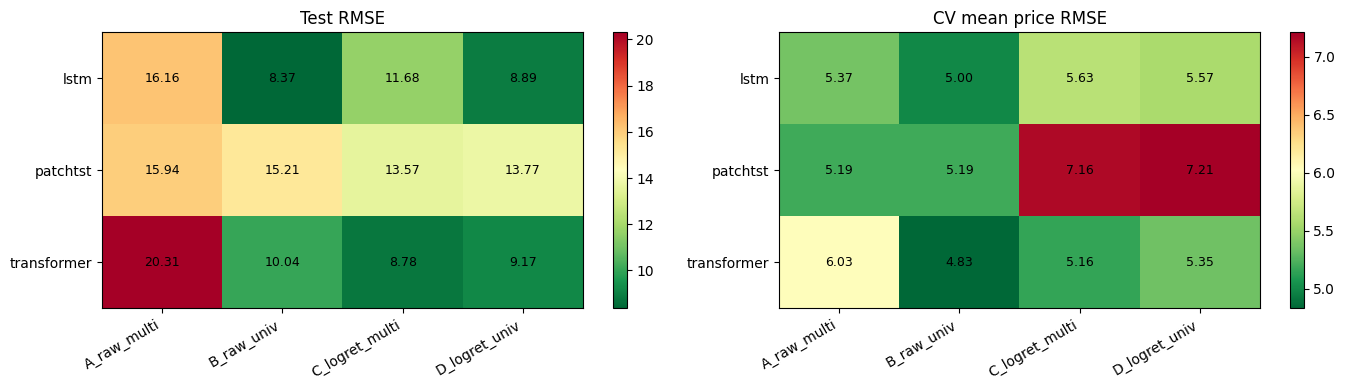

In [19]:
# 시각화: 실험 × 모델 heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (title, pivot) in zip(axes, [("Test RMSE", pivot_test_rmse), ("CV mean price RMSE", pivot_cv_rmse)]):
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title); plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


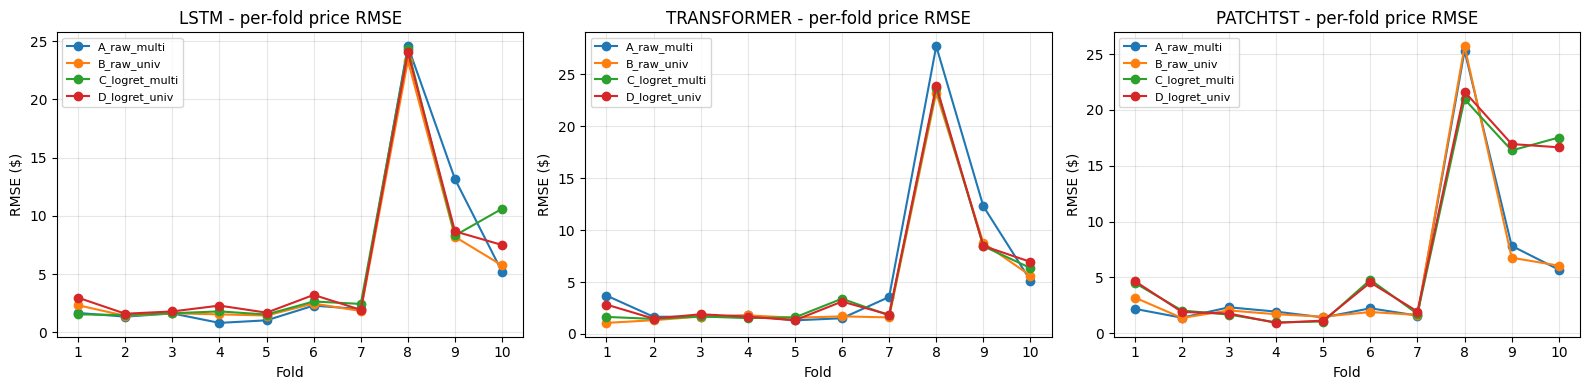

In [20]:
# Per-fold price RMSE 라인 (실험 간 안정성 비교)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
xs = np.arange(1, CFG.n_folds + 1)
for ax, name in zip(axes, MODELS):
    for exp_name, _ in EXPERIMENTS:
        rmses = results[exp_name][name]["cv"]["fold_price_rmses"]
        ax.plot(xs, rmses, marker="o", label=exp_name)
    ax.set_title(f"{name.upper()} - per-fold price RMSE")
    ax.set_xlabel("Fold"); ax.set_ylabel("RMSE ($)")
    ax.set_xticks(xs); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


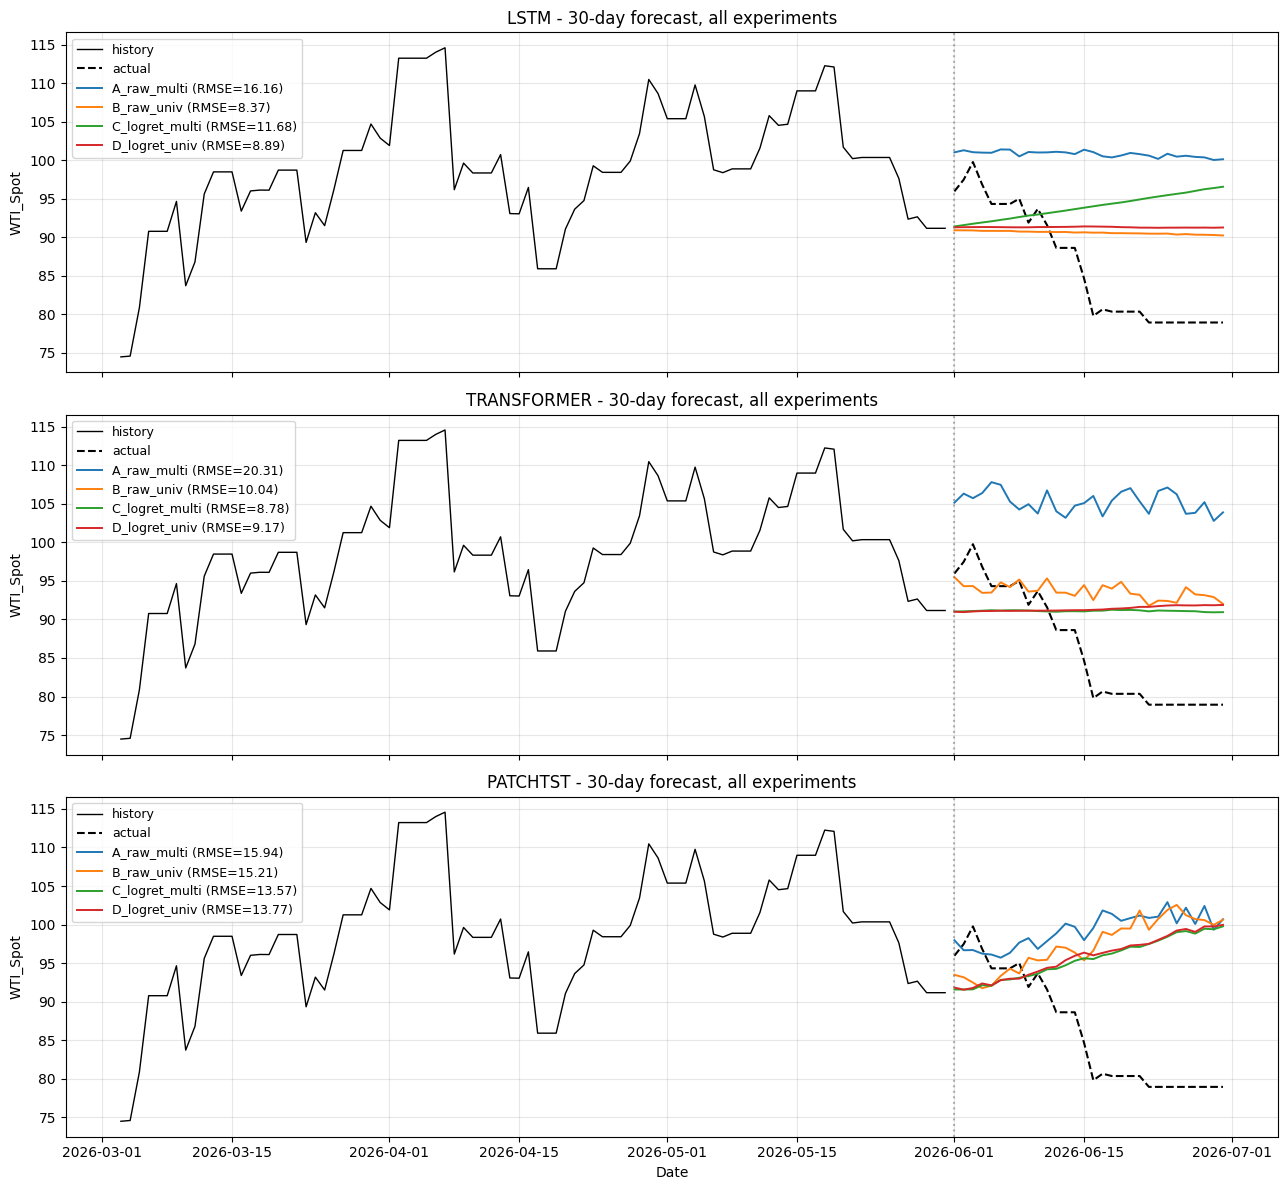

In [21]:
# 최종 30일 예측 시각화: 각 모델별로 4개 실험 겹쳐 그림
_, test_start = make_splits(df, CFG)
dates = df["Date"].values
context = 90
hist_d = dates[test_start - context : test_start]
hist_v = df[CFG.target_col].values[test_start - context : test_start]
fut_d = dates[test_start : test_start + CFG.forecast_horizon]
first_exp = EXPERIMENTS[0][0]
actual = results[first_exp][MODELS[0]]["final"]["actual"]

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
for ax, name in zip(axes, MODELS):
    ax.plot(hist_d, hist_v, color="black", lw=1.0, label="history")
    ax.plot(fut_d, actual, color="black", ls="--", lw=1.5, label="actual")
    for exp_name, _ in EXPERIMENTS:
        pred = results[exp_name][name]["final"]["pred"]
        rmse = results[exp_name][name]["final"]["metrics"]["RMSE"]
        ax.plot(fut_d, pred, lw=1.4, label=f"{exp_name} (RMSE={rmse:.2f})")
    ax.axvline(dates[test_start], color="gray", ls=":", alpha=0.6)
    ax.set_title(f"{name.upper()} - 30-day forecast, all experiments")
    ax.set_ylabel(CFG.target_col); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()


In [22]:
# 저장: 요약 CSV + 예측 CSV + 메타 JSON
summary.to_csv("experiments_summary.csv")

records = []
for i, d in enumerate(fut_d):
    row = {"Date": pd.Timestamp(d).date(), "actual": float(actual[i])}
    for exp_name, _ in EXPERIMENTS:
        for name in MODELS:
            row[f"{exp_name}_{name}"] = float(results[exp_name][name]["final"]["pred"][i])
    records.append(row)
pd.DataFrame(records).to_csv("experiments_forecasts.csv", index=False)

meta = {
    exp_name: {
        name: {
            "test_metrics": results[exp_name][name]["final"]["metrics"],
            "cv_mean_price_RMSE": results[exp_name][name]["cv"]["mean_price_rmse"],
            "cv_std_price_RMSE": results[exp_name][name]["cv"]["std_price_rmse"],
            "cv_mean_val_MSE_scaled": results[exp_name][name]["cv"]["mean_val_loss"],
            "fold_price_rmses": results[exp_name][name]["cv"]["fold_price_rmses"],
            "fold_best_epochs": results[exp_name][name]["cv"]["fold_best_epochs"],
            "final_epochs": results[exp_name][name]["final"]["final_epochs"],
            "n_channels": len(results[exp_name][name]["channel_names"]),
        }
        for name in MODELS
    }
    for exp_name, _ in EXPERIMENTS
}
with open("experiments_meta.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)
print("saved experiments_summary.csv, experiments_forecasts.csv, experiments_meta.json")


saved experiments_summary.csv, experiments_forecasts.csv, experiments_meta.json


## 10. Optuna 튜닝 (선택한 실험에 대해서만)

12 configuration × 10 fold × 20 trial 은 너무 큽니다.
**Section 9 결과를 보고 가장 유망한 실험 조합 1개** 를 골라 Optuna 를 돌리세요.

아래 셀에서 `TARGET_EXPERIMENT` 만 바꾸면 됩니다.


In [ ]:
# ==== Optuna 대상 실험 선택 ====
TARGET_EXPERIMENT = "A_raw_multi"   # "A_raw_multi" | "B_raw_univ" | "C_logret_multi" | "D_logret_univ"
N_TRIALS = 20
TUNE_EPOCHS = 30
TUNE_PATIENCE = 6

_exp_overrides = dict(EXPERIMENTS)[TARGET_EXPERIMENT]
base_cfg = cfg_with_overrides(CFG, _exp_overrides)
base_prep = prepare_arrays(df, base_cfg)
print(f"Optuna target: {TARGET_EXPERIMENT}  overrides={_exp_overrides}")
print(f"  channels ({base_prep['X'].shape[1]}): {base_prep['channel_names']}")


In [ ]:
def cfg_from_trial_common(trial, base):
    cfg = Config(**asdict(base))
    cfg.epochs = TUNE_EPOCHS; cfg.patience = TUNE_PATIENCE
    cfg.lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    cfg.weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    cfg.batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    cfg.lookback = trial.suggest_categorical("lookback", [30, 60, 96, 128])
    return cfg


def objective_factory(model_name, base, prep_fn):
    def objective(trial):
        cfg = cfg_from_trial_common(trial, base)
        if model_name == "lstm":
            cfg.lstm_hidden = trial.suggest_categorical("lstm_hidden", [64, 128, 256])
            cfg.lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
            cfg.lstm_dropout = trial.suggest_float("lstm_dropout", 0.0, 0.4)
        elif model_name == "transformer":
            cfg.tf_d_model = trial.suggest_categorical("tf_d_model", [32, 64, 128])
            cfg.tf_nhead = trial.suggest_categorical("tf_nhead", [2, 4, 8])
            cfg.tf_layers = trial.suggest_int("tf_layers", 1, 4)
            cfg.tf_dim_ff = trial.suggest_categorical("tf_dim_ff", [64, 128, 256])
            cfg.tf_dropout = trial.suggest_float("tf_dropout", 0.0, 0.4)
            if cfg.tf_d_model % cfg.tf_nhead != 0: raise optuna.TrialPruned()
        elif model_name == "patchtst":
            cfg.patch_len = trial.suggest_categorical("patch_len", [8, 16, 24])
            cfg.stride = trial.suggest_categorical("stride", [4, 8, 16])
            cfg.pt_d_model = trial.suggest_categorical("pt_d_model", [32, 64, 128])
            cfg.pt_nhead = trial.suggest_categorical("pt_nhead", [2, 4, 8])
            cfg.pt_layers = trial.suggest_int("pt_layers", 1, 4)
            cfg.pt_dim_ff = trial.suggest_categorical("pt_dim_ff", [64, 128, 256])
            cfg.pt_dropout = trial.suggest_float("pt_dropout", 0.0, 0.4)
            if cfg.pt_d_model % cfg.pt_nhead != 0: raise optuna.TrialPruned()
            if cfg.stride > cfg.patch_len: raise optuna.TrialPruned()

        # target_transform / use_exogenous 는 base 에서 이미 세팅됨
        prep = prep_fn(df, cfg)   # lookback 이 trial 마다 바뀔 수 있으니 재준비 (X, y 는 안 바뀜)
        cv = run_walkforward_cv(model_name, cfg, prep, verbose=False)
        trial.set_user_attr("fold_best_epochs", cv["fold_best_epochs"])
        trial.set_user_attr("fold_best_losses", cv["fold_val_losses"])
        trial.set_user_attr("mean_best_epoch", cv["mean_best_epoch"])
        return cv["mean_val_loss"]
    return objective


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

studies = {}
for name in MODELS:
    print(f"\n===== [OPTUNA {TARGET_EXPERIMENT} | {name.upper()}] =====")
    sampler = optuna.samplers.TPESampler(seed=CFG.seed)
    study = optuna.create_study(direction="minimize", sampler=sampler,
                                study_name=f"{name}_{TARGET_EXPERIMENT}")
    study.optimize(objective_factory(name, base_cfg, prepare_arrays),
                   n_trials=N_TRIALS, show_progress_bar=True)
    print(f"  best mean_val_loss = {study.best_value:.5f}")
    print(f"  best params = {study.best_params}")
    studies[name] = study


In [ ]:
# 최종 재학습 (Optuna best HP 로)
optuna_final = {}
for name in MODELS:
    print(f"\n===== [OPTUNA-FINAL {TARGET_EXPERIMENT} | {name.upper()}] =====")
    st = studies[name]
    cfg = Config(**asdict(base_cfg))
    for k, v in st.best_params.items(): setattr(cfg, k, v)
    prep = prepare_arrays(df, cfg)
    dummy_cv = {"mean_best_epoch": st.best_trial.user_attrs["mean_best_epoch"]}
    res = final_retrain_and_test(name, cfg, prep, dummy_cv)
    print(f"  test metrics: {res['metrics']}   (epochs={res['final_epochs']})")
    res["study"] = st
    optuna_final[name] = res


In [ ]:
# Fixed vs Optuna 비교 (선택된 실험 안에서)
cmp_rows = []
for name in MODELS:
    fx = results[TARGET_EXPERIMENT][name]["final"]["metrics"]
    op = optuna_final[name]["metrics"]
    cmp_rows.append({
        "model": name,
        "fixed_RMSE": fx["RMSE"], "optuna_RMSE": op["RMSE"],
        "fixed_MAE":  fx["MAE"],  "optuna_MAE":  op["MAE"],
        "fixed_MAPE(%)": fx["MAPE(%)"], "optuna_MAPE(%)": op["MAPE(%)"],
    })
pd.DataFrame(cmp_rows).set_index("model")


## 정리 및 사용 팁

**실험 구성 요약**
- 4개 실험 (raw vs log-return × multivariate vs univariate) × 3 모델 = 12 configuration
- 각 configuration: 10-fold walk-forward CV → mean(best_epoch) 로 재학습 → test 30일 예측
- 실험 간 공정 비교 위해 test metrics 는 항상 **원 가격 스케일** ($ 단위)

**주요 관찰 포인트**
1. **log-return 이 raw 보다 좋은가?**: 시계열의 비정상성 완화 효과. 다만 30일 direct 예측에서는 return 예측 오차가 누적되므로 항상 좋진 않음.
2. **univariate 가 multivariate 보다 좋은가?**: 외생변수가 정말 예측력이 있는지 판단. 특히 WTI_Futures 가 현물과 강한 동기화면 우려한 look-ahead 효과가 있을 수 있음 → univariate가 지면 반대로 정보 손실.
3. **fold-별 RMSE 편차**: 특정 fold(예: 변동성이 큰 구간) 에서 큰 성능 저하가 있으면 그 구간의 특수성 조사 필요.

**연산 비용**
- Fixed 스윕: 4 exp × 3 model × 10 fold × ~60 epoch = **최대 7200 model-epoch** (CPU 는 수 시간, GPU 는 30분~1h)
- Optuna 는 그 위에 20 trial × 10 fold ≈ **6000 model-epoch/모델** 추가 → **선택한 실험 1개에만** 돌리는 걸 강력히 권장.

**주의: log_shift 값 확인**
- 기본값 50 → 최소 가격 -37 을 +13 으로 만듦 (충분히 양수)
- 데이터 범위가 다르면 `CFG.log_shift` 를 조정하세요 (assertion 이 걸릴 겁니다).
